# EDA — gold layer & PLAsTiCC data

Exploratory analysis of the **training-ready** artefacts produced by the gold stage of `build_dataset.ipynb`, plus the **PLAsTiCC** simulated dataset used for the simulated-vs-real comparison (RQ3).

This picks up where `eda.ipynb` (bronze + silver) left off. Silver gave us one cleaned, ZTF-resolved, labelled object per row. **Gold** turns each surviving object into the two things the classifier actually consumes — a **tabular feature vector** and a **3-channel image stamp** — plus the labels, metadata and splits that wrap them.

### What the gold layer is

The gold stage walks every silver `oid`, and for each one fetches from ALeRCE:

1. **object metadata** (`ndet`, `firstmjd`, `lastmjd`) — used for the >=`min_detections` quality cut and the time-ordered split;
2. a **light-curve feature vector** (`query_features`) — the ALeRCE / `turbo-fats` statistical descriptors, pivoted to one wide row per object;
3. a **63x63x3 image stamp** (`get_stamps`) — the science, reference (template) and difference cutouts at the object's position.

Only objects that end up with **both** a feature vector **and** a stamp are kept (the dataset is strictly *multimodal*). The result is six files in `data/gold/`:

| File | Shape | Role |
|---|---|---|
| `gold_features.parquet` | N x (1 + F) | tabular branch — `oid` + F light-curve features |
| `gold_stamps.npz` | N x 3 x 63 x 63 | image branch — science / reference / difference cutouts |
| `gold_labels.parquet` | N x 4 | targets — `coarse`, `fine`, `plasticc_class` |
| `gold_metadata.parquet` | N x 8 | `ra/dec/redshift/source/ndet/firstmjd/lastmjd` (not fed to the model; for analysis & splitting) |
| `gold_splits.parquet` | N x 3 | time-ordered `train/val/test` assignment per `oid` |
| `MANIFEST.json` | — | config snapshot + counts for reproducibility |

### What gets fed to the classifier

- **Inputs (X):** two parallel branches keyed by `oid` —
  - **tabular:** the F-column feature matrix from `gold_features.parquet` (per-band light-curve statistics);
  - **image:** the `(3, 63, 63)` stamp tensor from `gold_stamps.npz`.
- **Target (y):** the class label from `gold_labels.parquet` — `coarse` in {SN, AGN, VS} for the main head-to-head task, with `fine` (subtype) as the stretch objective and `plasticc_class` as the bridge to the simulated PLAsTiCC labels.
- **Metadata** (`ra`, `dec`, `redshift`, `source`, `ndet`, ...) is **not** a model input — it is kept for stratified analysis, leakage checks and the time-based split.

This notebook audits all of that: feature coverage/missingness, the stamp tensor, the label balance *after* the quality cut, the split design, and finally the PLAsTiCC dataset that the real ZTF gold set will be compared against.

## Setup

In [27]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

plt.rcParams['figure.dpi'] = 110
plt.rcParams['axes.grid'] = True
plt.rcParams['grid.alpha'] = 0.3

DATA = Path('data')
GOLD = DATA/'gold'
PLASTICC = Path('plasticc_data')

# same coarse-class palette as the bronze/silver EDA, for visual continuity
COARSE_COLORS = {'SN':'#d1495b', 'AGN':'#30638e', 'VS':'#edae49'}

def bar_labels(ax, fmt='{:,.0f}'):
    """annotate each bar with its height"""
    for p in ax.patches:
        h = p.get_height()
        if h and not np.isnan(h):
            ax.annotate(fmt.format(h), (p.get_x()+p.get_width()/2, h),
                        ha='center', va='bottom', fontsize=9, xytext=(0,2),
                        textcoords='offset points')
print('setup ready')

setup ready


## Part 1 — Gold layer

### Load the gold artefacts

The five data files plus the manifest. Everything is joined on `oid`, the ZTF object identifier that is the primary key across all gold tables and the stamp tensor.

In [28]:
man = json.loads((GOLD/'MANIFEST.json').read_text())

feat = pd.read_parquet(GOLD/'gold_features.parquet')
lab  = pd.read_parquet(GOLD/'gold_labels.parquet')
meta = pd.read_parquet(GOLD/'gold_metadata.parquet')
spl  = pd.read_parquet(GOLD/'gold_splits.parquet')

npz   = np.load(GOLD/'gold_stamps.npz', allow_pickle=True)
X_img = npz['stamps']                 # (N, 3, 63, 63)
oids  = npz['oids'].astype(str)       # row -> oid, aligned to X_img
channels = [str(c) for c in npz['channels']]

print('features :', feat.shape)
print('labels   :', lab.shape)
print('metadata :', meta.shape)
print('splits   :', spl.shape)
print('stamps   :', X_img.shape, '| channels:', channels)
print('\nmanifest: n_objects=%d, n_features=%d, stamp_shape=%s'
      % (man['n_objects'], man['n_features'], man['stamp_shape']))

features : (11826, 268)
labels   : (11826, 4)
metadata : (11826, 8)
splits   : (11826, 3)
stamps   : (11826, 3, 63, 63) | channels: ['science', 'reference', 'difference']

manifest: n_objects=11826, n_features=267, stamp_shape=[11826, 3, 63, 63]


### Key integrity check — do all four tables + the stamp tensor agree on `oid`?

If the branches are mis-aligned, every downstream join silently corrupts the labels. This must be a clean pass before any modelling.

In [29]:
sets = {
    'features': set(feat['oid']),
    'labels'  : set(lab['oid']),
    'metadata': set(meta['oid']),
    'splits'  : set(spl['oid']),
    'stamps'  : set(oids),
}
base = sets['features']
print('N per table:', {k: len(v) for k, v in sets.items()})
print('all tables share an identical oid set:',
      all(v == base for v in sets.values()))
print('oids unique in features:', feat['oid'].is_unique,
      '| stamps:', len(oids) == len(set(oids)))

N per table: {'features': 11826, 'labels': 11826, 'metadata': 11826, 'splits': 11826, 'stamps': 11826}
all tables share an identical oid set: True
oids unique in features: True | stamps: True


### How many objects survived the gold stage?

Silver held 14,378 labelled objects; gold keeps only those with **>= `min_detections` detections AND both a feature vector and a stamp**. The drop is the cost of demanding a complete multimodal record.

In [30]:
n_silver = 14378  # from the silver EDA / build log
n_gold = len(feat)
print(f'silver labelled objects : {n_silver:,}')
print(f'gold complete records   : {n_gold:,}')
print(f'retained                : {100*n_gold/n_silver:.1f}%')
print(f'dropped (no feats/stamp / too few det): {n_silver-n_gold:,}')

silver labelled objects : 14,378
gold complete records   : 11,826
retained                : 82.3%
dropped (no feats/stamp / too few det): 2,552


### Coarse class distribution (gold)

The headline balance the classifier sees. Compare against silver: the quality cut is **not class-neutral** — minority AGN and short-lived variables lose a larger share, so the imbalance the model trains on is what matters here, not the silver counts.

        count   pct
coarse             
SN       7728  65.3
VS       3517  29.7
AGN       581   4.9

imbalance ratio (max/min): 13.3x


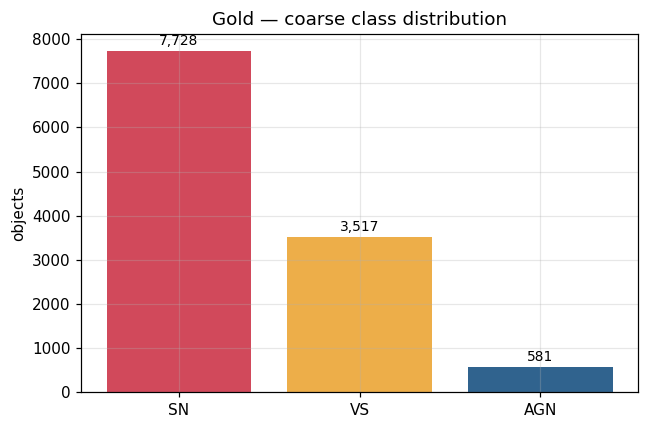

In [31]:
vc = lab['coarse'].value_counts()
pct = (vc/vc.sum()*100).round(1)
print(pd.DataFrame({'count': vc, 'pct': pct}))
print(f'\nimbalance ratio (max/min): {vc.max()/vc.min():.1f}x')

fig, ax = plt.subplots(figsize=(6,4))
ax.bar(vc.index, vc.values, color=[COARSE_COLORS[c] for c in vc.index])
ax.set_ylabel('objects'); ax.set_title('Gold — coarse class distribution')
bar_labels(ax); plt.tight_layout(); plt.show()

### Fine class distribution

Subtypes, coloured by their coarse parent. This is the target for the stretch (fine-grained) objective; note the long tail of rare SN subtypes with only tens of examples.

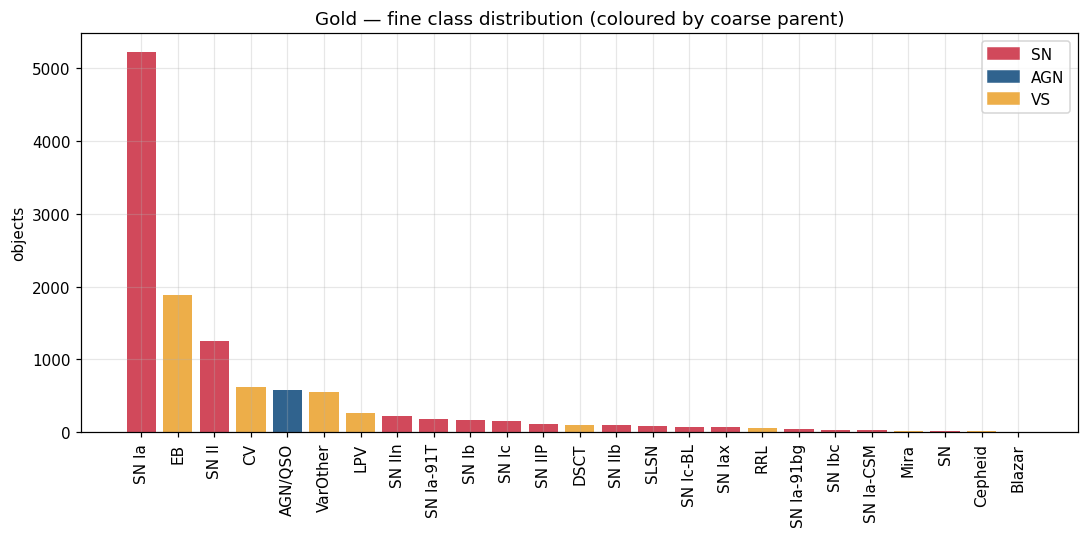

,count
fine,
SN Ia,5224
EB,1889
SN II,1252
CV,625
AGN/QSO,580
VarOther,557
LPV,256
SN IIn,227
SN Ia-91T,179


In [32]:
fine_to_coarse = (lab.dropna(subset=['fine'])
                  .groupby('fine')['coarse'].agg(lambda x: x.mode().iat[0]))
fvc = lab['fine'].value_counts()
colors = [COARSE_COLORS.get(fine_to_coarse.get(f), '#999999') for f in fvc.index]

fig, ax = plt.subplots(figsize=(10,5))
ax.bar(range(len(fvc)), fvc.values, color=colors)
ax.set_xticks(range(len(fvc))); ax.set_xticklabels(fvc.index, rotation=90)
ax.set_ylabel('objects'); ax.set_title('Gold — fine class distribution (coloured by coarse parent)')
from matplotlib.patches import Patch
ax.legend(handles=[Patch(color=c, label=k) for k,c in COARSE_COLORS.items()])
plt.tight_layout(); plt.show()
fvc.to_frame('count')

### The tabular branch — feature matrix anatomy

`gold_features.parquet` is the first model input. Each non-`oid` column is an ALeRCE light-curve feature. Names follow `<feature>_<fid>`:

- suffix **`_1`** = ZTF **g** band, **`_2`** = ZTF **r** band (the same statistic computed per band),
- suffix **`_0`** = band-independent (e.g. coordinates),
- **no suffix** = a single scalar for the object.

So one *physical* feature like `Amplitude` appears twice (g and r). Below: how many columns, how many distinct base features, and the per-band breakdown.

In [33]:
import re
fcols = [c for c in feat.columns if c != 'oid']
base = sorted(set(re.sub(r'_\d+$', '', c) for c in fcols))

band = {'1 (g)':0, '2 (r)':0, '0 (coord/other)':0, 'no suffix':0, 'other':0}
for c in fcols:
    if   c.endswith('_1'): band['1 (g)'] += 1
    elif c.endswith('_2'): band['2 (r)'] += 1
    elif c.endswith('_0'): band['0 (coord/other)'] += 1
    elif re.search(r'_\d+$', c) is None: band['no suffix'] += 1
    else: band['other'] += 1

print(f'feature columns        : {len(fcols)}')
print(f'distinct base features : {len(base)}')
print('per-band column counts :')
for k,v in band.items(): print(f'   {k:18s}: {v}')
print('\nexample base features:', base[:25])

feature columns        : 267
distinct base features : 151
per-band column counts :
   1 (g)             : 105
   2 (r)             : 105
   0 (coord/other)   : 25
   no suffix         : 0
   other             : 32

example base features: ['Amplitude', 'AndersonDarling', 'Autocor_length', 'Beyond1Std', 'Con', 'Coordinate_x', 'Coordinate_y', 'Coordinate_z', 'Eta_e', 'ExcessVar', 'GP_DRW_sigma', 'GP_DRW_tau', 'Gskew', 'Harmonics_chi', 'Harmonics_mag_1', 'Harmonics_mag_2', 'Harmonics_mag_3', 'Harmonics_mag_4', 'Harmonics_mag_5', 'Harmonics_mag_6', 'Harmonics_mag_7', 'Harmonics_mse', 'Harmonics_phase_2', 'Harmonics_phase_3', 'Harmonics_phase_4']


### Feature missingness

ALeRCE only computes a feature when the light curve supports it (enough points, both bands, a WISE cross-match, ...). Missingness is therefore **informative but heavy** — the model/pipeline must impute. Columns that are ~100% missing are effectively dead and candidates for dropping.

mean missing across features  : 37.8%
fully-present features (0% NaN): 0 / 267
dead features (>=99% NaN)     : 15


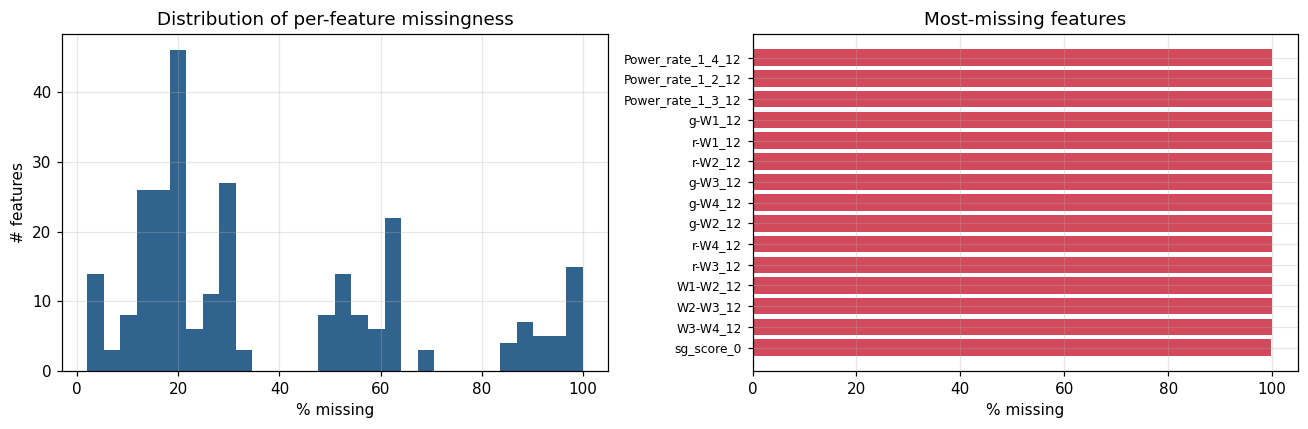

In [34]:
miss = (feat[fcols].isna().mean()*100)
print(f'mean missing across features  : {miss.mean():.1f}%')
print(f'fully-present features (0% NaN): {(miss==0).sum()} / {len(fcols)}')
print(f'dead features (>=99% NaN)     : {(miss>=99).sum()}')

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].hist(miss, bins=30, color='#30638e')
ax[0].set_xlabel('% missing'); ax[0].set_ylabel('# features')
ax[0].set_title('Distribution of per-feature missingness')

top = miss.sort_values(ascending=False).head(15)
ax[1].barh(range(len(top)), top.values, color='#d1495b')
ax[1].set_yticks(range(len(top))); ax[1].set_yticklabels(top.index, fontsize=8)
ax[1].invert_yaxis(); ax[1].set_xlabel('% missing')
ax[1].set_title('Most-missing features')
plt.tight_layout(); plt.show()

### Is the missingness random, or class-dependent?

The plot above shows *how much* is missing; the more important question for modelling is *whether the pattern leaks the label*. If a feature is systematically absent for one class and present for another, the classifier can learn "feature X is missing" as a proxy for the class — predicting on data-availability rather than physics, which will not transfer to deployment or to PLAsTiCC.

Below: per-class missingness for the most variable features, and the spread (max class − min class) that quantifies the class-dependence.

mean missingness per class:
coarse
AGN    30.3
SN     43.6
VS     26.3
dtype: float64

features whose missingness differs by >30 pp across classes: 70 / 267

most class-dependent features (spread, pp):
ulens_u0_1      74.0
ulens_tE_1      74.0
ulens_fs_1      74.0
ulens_t0_2      74.0
ulens_mag0_2    74.0
ulens_t0_1      74.0
ulens_chi_2     74.0
ulens_mag0_1    74.0
ulens_u0_2      74.0
ulens_tE_2      74.0


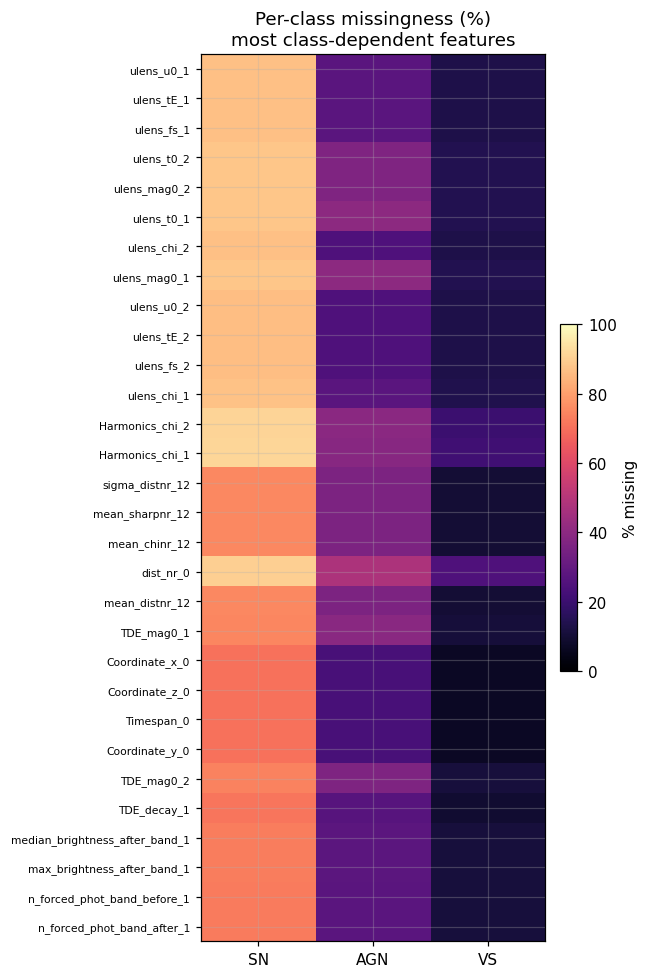

In [35]:
dfm = feat.merge(lab[['oid','coarse']], on='oid')
# missingness (%) of every feature, computed separately within each coarse class
pcm = dfm.groupby('coarse')[fcols].apply(lambda g: g.isna().mean()*100)
spread = (pcm.max() - pcm.min())          # max-min across classes, in percentage points

print('mean missingness per class:')
print(dfm.groupby('coarse')[fcols].apply(lambda g: g.isna().mean().mean()*100).round(1))
print(f'\nfeatures whose missingness differs by >30 pp across classes: '
      f'{(spread>30).sum()} / {len(fcols)}')
print('\nmost class-dependent features (spread, pp):')
print(spread.sort_values(ascending=False).head(10).round(0).to_string())

# heatmap: the 30 most class-dependent features x the three classes
top = spread.sort_values(ascending=False).head(30).index
H = pcm.loc[['SN','AGN','VS'], top].T      # rows=features, cols=classes
fig, ax = plt.subplots(figsize=(6, 9))
im = ax.imshow(H.values, aspect='auto', cmap='magma', vmin=0, vmax=100)
ax.set_xticks(range(3)); ax.set_xticklabels(['SN','AGN','VS'])
ax.set_yticks(range(len(top))); ax.set_yticklabels(top, fontsize=7)
ax.set_title('Per-class missingness (%)\nmost class-dependent features')
fig.colorbar(im, ax=ax, label='% missing', fraction=0.046, pad=0.04)
plt.tight_layout(); plt.show()

### The image branch — stamp tensor

`gold_stamps.npz` holds an `(N, 3, 63, 63)` float32 tensor. The three channels are the ZTF cutouts at the alert position:

- **science** — the new image,
- **reference** — the deep template,
- **difference** — science - reference (where the transient signal lives).

Below: dtype/range sanity, then the three cutouts for one example object of each coarse class.

dtype: float32 | shape: (11826, 3, 63, 63)
per-channel value ranges (after nan->0 in the pipeline):
   science    : min=-310  max=6.1e+04  mean=196
   reference  : min=-3.4e+38  max=4.84e+04  mean=-inf
   difference : min=-9.31e+03  max=5.2e+04  mean=0.532


c:\Users\Fatema\.conda\envs\cv_gpu\lib\site-packages\numpy\_core\_methods.py:135: RuntimeWarning: overflow encountered in reduce
  ret = umr_sum(arr, axis, dtype, out, keepdims, where=where)


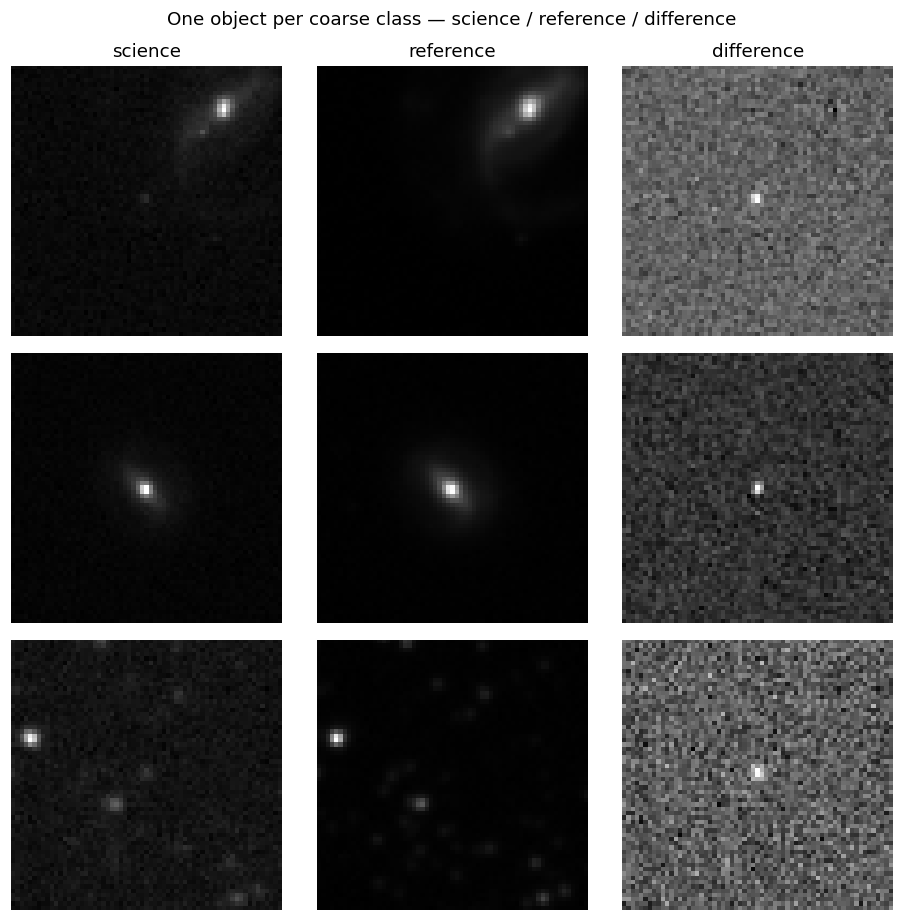

In [36]:
print('dtype:', X_img.dtype, '| shape:', X_img.shape)
print('per-channel value ranges (after nan->0 in the pipeline):')
for j, c in enumerate(channels):
    ch = X_img[:, j]
    print(f'   {c:11s}: min={ch.min():.3g}  max={ch.max():.3g}  mean={ch.mean():.3g}')

lab_by_oid = lab.set_index('oid')
oid_pos = {o: i for i, o in enumerate(oids)}
fig, axes = plt.subplots(3, 3, figsize=(8.5, 8.5))
for r, cls in enumerate(['SN', 'AGN', 'VS']):
    cls_oids = set(lab.loc[lab['coarse']==cls, 'oid'].values)
    idx = next(i for i, o in enumerate(oids) if o in cls_oids)
    o = oids[idx]; fine = lab_by_oid.loc[o, 'fine']
    for j, c in enumerate(channels):
        axes[r, j].imshow(X_img[idx, j], origin='lower', cmap='gray')
        axes[r, j].axis('off')
        if r == 0: axes[r, j].set_title(c)
    axes[r, 0].set_ylabel(f'{cls}\n{fine}', rotation=0, labelpad=40, va='center')
fig.suptitle('One object per coarse class — science / reference / difference')
plt.tight_layout(); plt.show()

### Metadata — `ndet`, redshift and sky position

Not model inputs, but they justify the dataset design. `ndet` confirms the quality floor; redshift presence and sky position confirm the labels are physically sane (extragalactic SN/AGN carry redshifts and are isotropic; Galactic variable stars cluster on the plane and mostly lack redshifts).

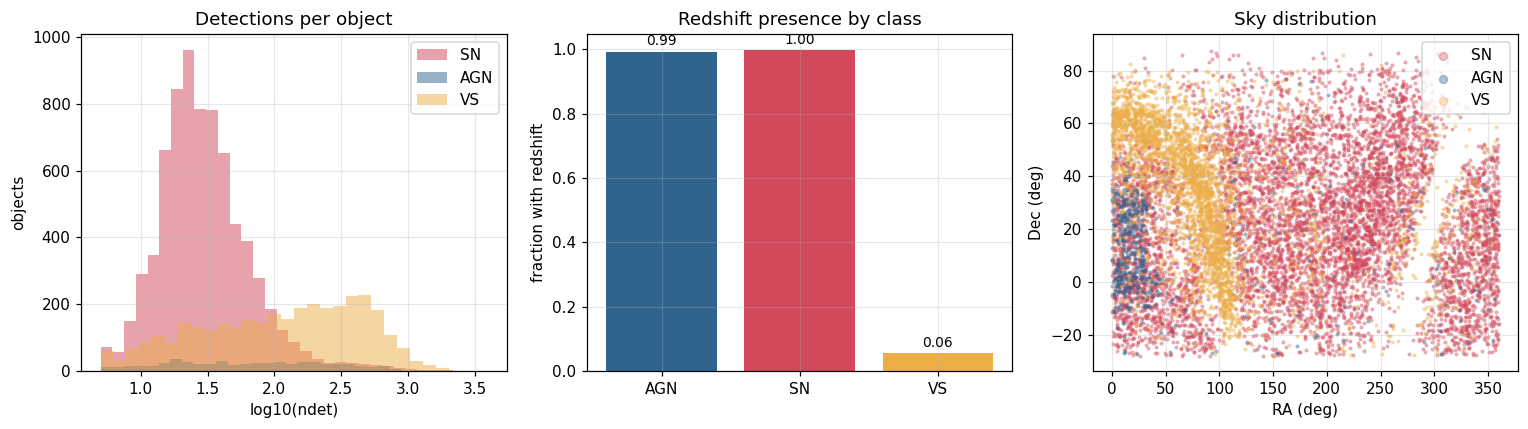

fraction with a redshift:
coarse
AGN    0.993
SN     0.997
VS     0.056
Name: redshift, dtype: float64


In [37]:
m = meta.merge(lab[['oid','coarse']], on='oid')

fig, ax = plt.subplots(1, 3, figsize=(14,4))
for c in ['SN','AGN','VS']:
    nd = m.loc[m['coarse']==c, 'ndet'].dropna()
    ax[0].hist(np.log10(nd.clip(lower=1)), bins=30, alpha=0.5, label=c, color=COARSE_COLORS[c])
ax[0].set_xlabel('log10(ndet)'); ax[0].set_ylabel('objects')
ax[0].set_title('Detections per object'); ax[0].legend()

frac = m.groupby('coarse')['redshift'].apply(lambda x: x.notna().mean()).round(3)
ax[1].bar(frac.index, frac.values, color=[COARSE_COLORS[c] for c in frac.index])
ax[1].set_ylabel('fraction with redshift'); ax[1].set_title('Redshift presence by class')
bar_labels(ax[1], fmt='{:.2f}')

for c in ['SN','AGN','VS']:
    sub = m[m['coarse']==c]
    ax[2].scatter(sub['ra'], sub['dec'], s=3, alpha=0.35, label=c, color=COARSE_COLORS[c])
ax[2].set_xlabel('RA (deg)'); ax[2].set_ylabel('Dec (deg)')
ax[2].set_title('Sky distribution'); ax[2].legend(markerscale=3)
plt.tight_layout(); plt.show()
print('fraction with a redshift:'); print(frac)

### The split — time-ordered train / val / test

`gold_splits.parquet` assigns each object wholly to one split, ordered by `firstmjd` (oldest -> train, newest -> test). This makes the test set strictly *future* relative to training, mimicking real deployment and preventing object leakage. Two things to verify: (1) the time ordering actually holds, and (2) every class is present in every split.

split x coarse:
coarse  AGN    SN    VS
split                  
train   403  4643  3232
val     117  1572    84
test     61  1513   201

split fractions: {'train': 0.7, 'val': 0.15, 'test': 0.15}


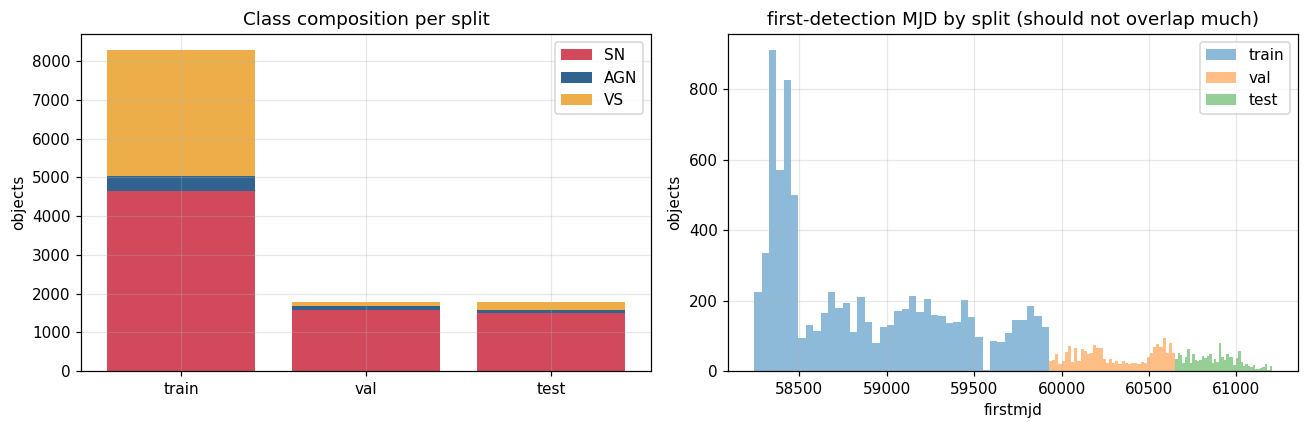

In [38]:
s = spl.merge(lab[['oid','coarse']], on='oid')
order = ['train','val','test']

ct = s.groupby(['split','coarse']).size().unstack(fill_value=0).reindex(order)
print('split x coarse:'); print(ct)
print('\nsplit fractions:', (spl['split'].value_counts(normalize=True)
                              .reindex(order).round(3).to_dict()))

fig, ax = plt.subplots(1, 2, figsize=(12,4))
bottom = np.zeros(len(ct))
for c in ['SN','AGN','VS']:
    ax[0].bar(ct.index, ct[c], bottom=bottom, label=c, color=COARSE_COLORS[c])
    bottom += ct[c].values
ax[0].set_ylabel('objects'); ax[0].set_title('Class composition per split'); ax[0].legend()

for sp in order:
    t = spl.loc[spl['split']==sp, 'firstmjd'].dropna()
    ax[1].hist(t, bins=40, alpha=0.5, label=sp)
ax[1].set_xlabel('firstmjd'); ax[1].set_ylabel('objects')
ax[1].set_title('first-detection MJD by split (should not overlap much)'); ax[1].legend()
plt.tight_layout(); plt.show()

### What the classifier receives — summary

Pulling the two branches together for a single `oid`, this is exactly one training example: a tabular vector **and** an image tensor sharing one label.

In [39]:
o = lab['oid'].iloc[0]
row_feat = feat.loc[feat['oid']==o, fcols]
row_img  = X_img[oid_pos[o]]
y = lab.loc[lab['oid']==o, ['coarse','fine','plasticc_class']].iloc[0].to_dict()

print(f'oid           : {o}')
print(f'X_tabular     : {row_feat.shape[1]} features '
      f'({int(row_feat.notna().sum().sum())} present, '
      f'{int(row_feat.isna().sum().sum())} missing)')
print(f'X_image       : {row_img.shape}  (3 x 63 x 63)')
print(f'y (target)    : {y}')
print(f'split         : {spl.loc[spl.oid==o, "split"].iat[0]}')

oid           : ZTF19aaydtur
X_tabular     : 267 features (170 present, 97 missing)
X_image       : (3, 63, 63)  (3 x 63 x 63)
y (target)    : {'coarse': 'SN', 'fine': 'SN II', 'plasticc_class': 'SNII'}
split         : train


## Part 2 — PLAsTiCC data

The Photometric LSST Astronomical Time-Series Classification Challenge (PLAsTiCC) is a **simulated** catalogue of LSST light curves with known types. It is used here for **RQ3**: train on simulation, test on the real ZTF gold set (and vice-versa), to measure the sim-to-real gap.

The download (`download_plasticc.py`, Zenodo record 2539456) gives:

| File | Content |
|---|---|
| `plasticc_train_metadata.csv.gz` | one row per training object: position, host-galaxy redshifts, true type (`target`) |
| `plasticc_train_lightcurves.csv.gz` | the training light curves (flux time series, 6 LSST passbands) |
| `plasticc_test_metadata.csv.gz` | metadata for the large unblinded test set |
| `plasticc_test_lightcurves_01..11.csv.gz` | the test light curves, split into 11 chunks (~7 GB) |
| `plasticc_modelpar.tar.gz`, `note*.pdf` | model parameters and the data-release notes |

We profile the **train** split here (the test light curves are ~7 GB and only loaded at modelling time).

### Load PLAsTiCC train metadata

The metadata table is the label source. `target` is the integer class code; `true_target` matches it for the unblinded train set. `hostgal_specz`/`hostgal_photoz` give the host-galaxy redshift (0 => Galactic).

In [40]:
pmeta = pd.read_csv(PLASTICC/'plasticc_train_metadata.csv.gz')
print('train metadata:', pmeta.shape)
print('columns:', pmeta.columns.tolist())
pmeta.head(3)

train metadata: (7848, 26)
columns: ['object_id', 'ra', 'decl', 'ddf_bool', 'hostgal_specz', 'hostgal_photoz', 'hostgal_photoz_err', 'distmod', 'mwebv', 'target', 'true_target', 'true_submodel', 'true_z', 'true_distmod', 'true_lensdmu', 'true_vpec', 'true_rv', 'true_av', 'true_peakmjd', 'libid_cadence', 'tflux_u', 'tflux_g', 'tflux_r', 'tflux_i', 'tflux_z', 'tflux_y']


,object_id,ra,decl,ddf_bool,hostgal_specz,hostgal_photoz,hostgal_photoz_err,distmod,mwebv,target,...,true_rv,true_av,true_peakmjd,libid_cadence,tflux_u,tflux_g,tflux_r,tflux_i,tflux_z,tflux_y
0,615,349.0461,-61.9438,1,0.000,0.000,0.000,-9.000,0.017,92,...,0.0,0.0,59570.000,69,484.7,3286.7,3214.1,3039.7,2854.5,2837.0
1,713,53.0859,-27.7844,1,1.818,1.627,0.255,45.406,0.007,88,...,0.0,0.0,59570.000,34,108.7,117.7,119.9,149.6,147.9,150.5
2,730,33.5742,-6.5796,1,0.232,0.226,0.016,40.256,0.021,42,...,0.0,0.0,60444.379,9,0.0,0.0,0.0,0.0,0.0,0.0


### Class (`target`) distribution

PLAsTiCC class codes map to physical types as below. The training set is small and imbalanced (SNIa-90 dominate), and the test set follows a *different*, deliberately harder distribution — relevant when interpreting RQ3 transfer results.

 code             name  count  galactic
   90             SNIa   2313     False
   42             SNII   1193     False
   65          M-dwarf    981      True
   16               EB    924      True
   15              TDE    495     False
   62            SNIbc    484     False
   88              AGN    370     False
   92              RRL    239      True
   67        SNIa-91bg    208     False
   52            SNIax    183     False
   95           SLSN-I    175     False
    6 microlens-single    151      True
   64               KN    102     False
   53             Mira     30      True


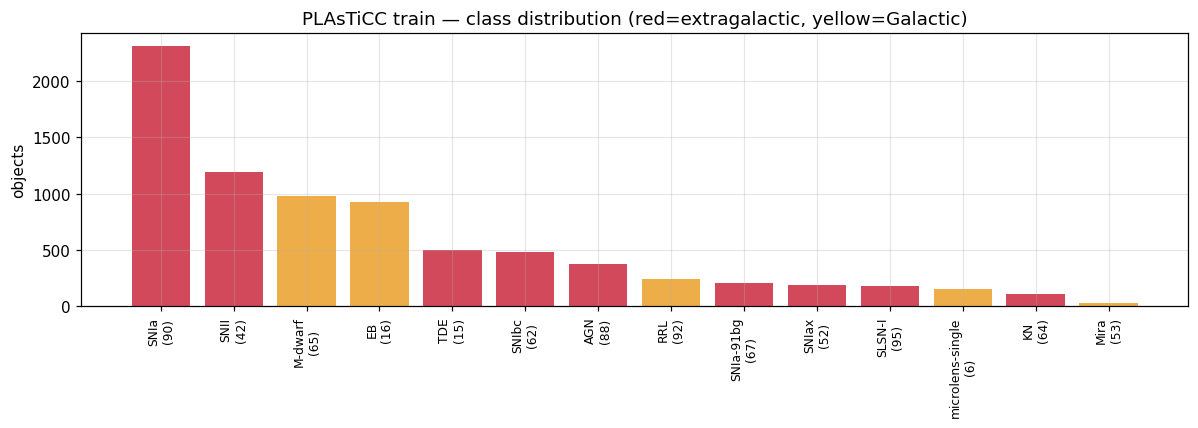

In [41]:
# Standard PLAsTiCC class-code -> name map (note2_modelNames). 99 = unknown/novel.
PLASTICC_NAMES = {
    90:'SNIa', 67:'SNIa-91bg', 52:'SNIax', 42:'SNII', 62:'SNIbc',
    95:'SLSN-I', 15:'TDE', 64:'KN', 88:'AGN', 92:'RRL', 65:'M-dwarf',
    16:'EB', 53:'Mira', 6:'microlens-single', 991:'mu-Lens-Binary',
    992:'ILOT', 993:'CaRT', 994:'PISN', 99:'unknown',
}
GALACTIC = {65, 16, 53, 6, 92, 991}  # codes that live in the Milky Way

vc = pmeta['target'].value_counts().sort_values(ascending=False)
tab = pd.DataFrame({
    'code': vc.index,
    'name': [PLASTICC_NAMES.get(c, str(c)) for c in vc.index],
    'count': vc.values,
    'galactic': [c in GALACTIC for c in vc.index],
})
print(tab.to_string(index=False))

fig, ax = plt.subplots(figsize=(11,4))
cols = ['#edae49' if g else '#d1495b' for g in tab['galactic']]
ax.bar(range(len(tab)), tab['count'], color=cols)
ax.set_xticks(range(len(tab)))
ax.set_xticklabels([f'{n}\n({c})' for n,c in zip(tab['name'], tab['code'])], rotation=90, fontsize=8)
ax.set_ylabel('objects')
ax.set_title('PLAsTiCC train — class distribution (red=extragalactic, yellow=Galactic)')
plt.tight_layout(); plt.show()

### Galactic vs extragalactic & redshift

A defining PLAsTiCC feature: objects split cleanly into Galactic (host redshift = 0) and extragalactic (host redshift > 0). Models exploit this. We confirm it against the host-galaxy photo-z.

host photo-z == 0 fraction, by code family:
is_galactic_code
False    0.0
True     1.0
Name: hostgal_photoz, dtype: float64


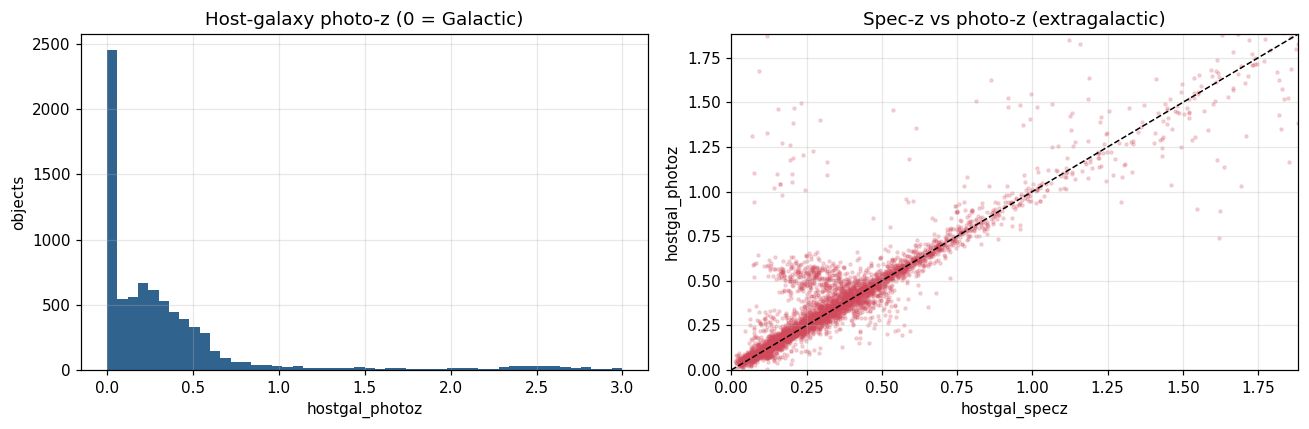

In [42]:
pmeta['is_galactic_code'] = pmeta['target'].isin(GALACTIC)
print('host photo-z == 0 fraction, by code family:')
print(pmeta.groupby('is_galactic_code')['hostgal_photoz']
      .apply(lambda x: (x==0).mean()).round(3))

fig, ax = plt.subplots(1, 2, figsize=(12,4))
ax[0].hist(pmeta['hostgal_photoz'].clip(0, 3.5), bins=50, color='#30638e')
ax[0].set_xlabel('hostgal_photoz'); ax[0].set_ylabel('objects')
ax[0].set_title('Host-galaxy photo-z (0 = Galactic)')

ext = pmeta[pmeta['hostgal_specz']>0]
ax[1].scatter(ext['hostgal_specz'], ext['hostgal_photoz'], s=4, alpha=0.2, color='#d1495b')
lim = [0, ext['hostgal_specz'].quantile(0.99)]
ax[1].plot(lim, lim, 'k--', lw=1)
ax[1].set_xlim(lim); ax[1].set_ylim(lim)
ax[1].set_xlabel('hostgal_specz'); ax[1].set_ylabel('hostgal_photoz')
ax[1].set_title('Spec-z vs photo-z (extragalactic)')
plt.tight_layout(); plt.show()

### Light-curve structure

The light-curve files are the actual time series. Each row is one flux measurement: `(object_id, mjd, passband, flux, flux_err, detected_bool)`. `passband` 0-5 ≈ LSST *u g r i z y*. Unlike ZTF gold (which stores *pre-computed features* + image stamps), PLAsTiCC is delivered as **raw photometry** — features have to be derived before the two datasets are comparable.

train light-curve rows: 1,421,705 | columns: ['object_id', 'mjd', 'passband', 'flux', 'flux_err', 'detected_bool']
objects: 7848
points per object: median=136, min=47, max=352


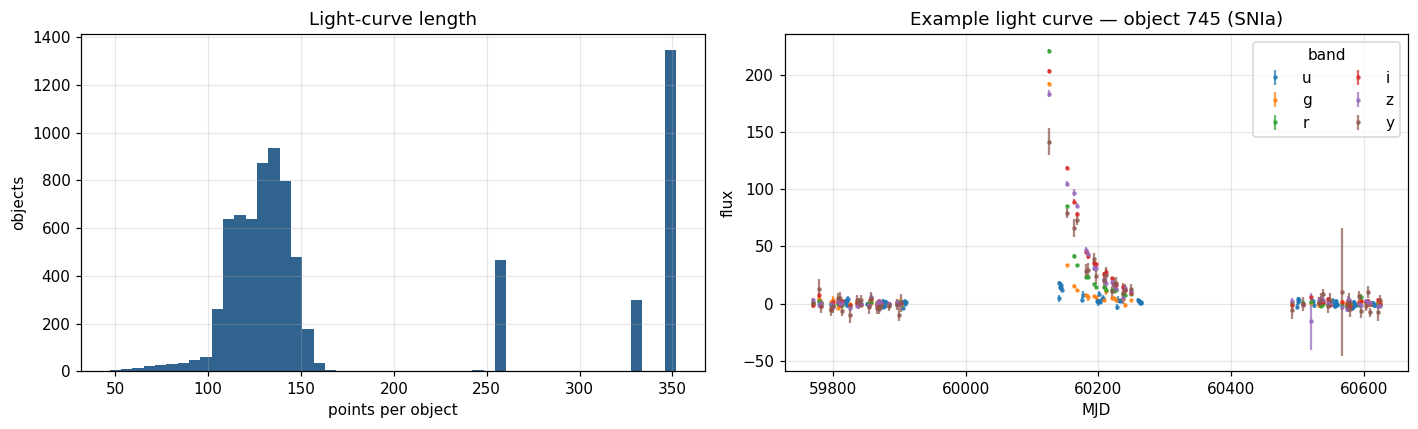

In [ ]:
plc = pd.read_csv(PLASTICC/'plasticc_train_lightcurves.csv.gz')
print('train light-curve rows:', f'{len(plc):,}', '| columns:', plc.columns.tolist())
print('objects:', plc['object_id'].nunique())
per_obj = plc.groupby('object_id').size()
print(f'points per object: median={per_obj.median():.0f}, '
      f'min={per_obj.min()}, max={per_obj.max()}')

PB = {0:'u',1:'g',2:'r',3:'i',4:'z',5:'y'}
fig, ax = plt.subplots(1, 2, figsize=(13,4))
ax[0].hist(per_obj, bins=50, color='#30638e')
ax[0].set_xlabel('points per object'); ax[0].set_ylabel('objects')
ax[0].set_title('Light-curve length')

oid_ex = pmeta.loc[pmeta['target']==90, 'object_id'].iloc[0]   # an SNIa
sub = plc[plc['object_id']==oid_ex]
for pb, g in sub.groupby('passband'):
    ax[1].errorbar(g['mjd'], g['flux'], yerr=g['flux_err'], fmt='.', ms=4,
                   alpha=0.7, label=PB.get(pb, pb))
ax[1].set_xlabel('MJD'); ax[1].set_ylabel('flux')
ax[1].set_title(f'Example light curve — object {oid_ex} (SNIa)')
ax[1].legend(title='band', ncol=2)
plt.tight_layout(); plt.show()

### Bridging gold <-> PLAsTiCC (RQ3)

The comparison only works on classes present in **both** datasets. The gold `plasticc_class` column already names each ZTF object in PLAsTiCC's vocabulary; here we line that up against PLAsTiCC's own class names to see the overlap and the per-class sample sizes available on each side.

gold objects with a plasticc_class: 85.0%
classes usable for RQ3 (present in both): 10

                  gold (ZTF real)  plasticc (sim train)  in_both
SNIa                         5224                  2313     True
EB                           1889                   924     True
SNII                         1687                  1193     True
AGN                           581                   370     True
SNIbc                         410                   484     True
SLSN-I                         88                   175     True
SNIax                          63                   183     True
RRL                            58                   239     True
SNIa-91bg                      36                   208     True
Mira                           20                    30     True
KN                              0                   102    False
M-dwarf                         0                   981    False
TDE                             0                   495    False
mi

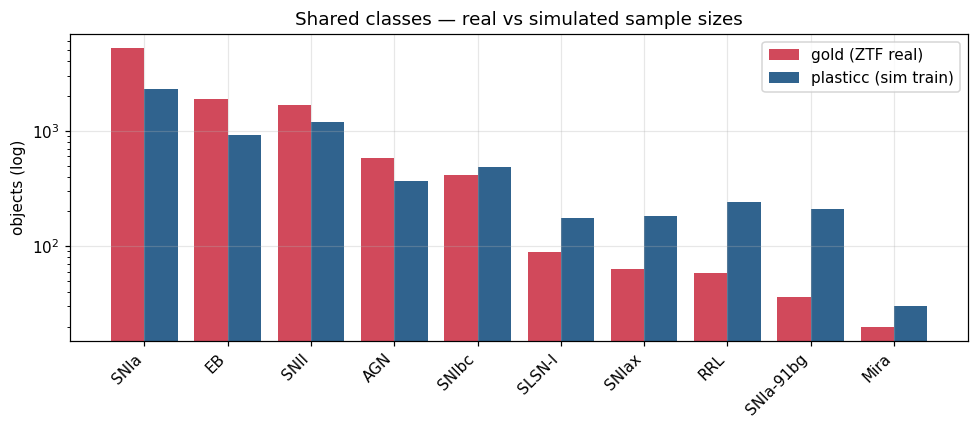

In [44]:
gold_pc = lab['plasticc_class'].value_counts()
plast_pc = pd.Series({PLASTICC_NAMES.get(c, str(c)): n
                      for c, n in pmeta['target'].value_counts().items()})

bridge = pd.DataFrame({'gold (ZTF real)': gold_pc, 'plasticc (sim train)': plast_pc})
bridge = bridge.fillna(0).astype(int)
bridge['in_both'] = (bridge['gold (ZTF real)']>0) & (bridge['plasticc (sim train)']>0)
bridge = bridge.sort_values('gold (ZTF real)', ascending=False)
print(f"gold objects with a plasticc_class: {lab['plasticc_class'].notna().mean()*100:.1f}%")
print(f"classes usable for RQ3 (present in both): {bridge['in_both'].sum()}")
print()
print(bridge.to_string())

shared = bridge[bridge['in_both']]
fig, ax = plt.subplots(figsize=(9,4))
x = np.arange(len(shared)); w = 0.4
ax.bar(x-w/2, shared['gold (ZTF real)'], w, label='gold (ZTF real)', color='#d1495b')
ax.bar(x+w/2, shared['plasticc (sim train)'], w, label='plasticc (sim train)', color='#30638e')
ax.set_yscale('log'); ax.set_xticks(x); ax.set_xticklabels(shared.index, rotation=45, ha='right')
ax.set_ylabel('objects (log)')
ax.set_title('Shared classes — real vs simulated sample sizes'); ax.legend()
plt.tight_layout(); plt.show()

## Takeaways

**Gold layer**
- **Multimodal completeness costs objects.** ~82% of silver survives the "features AND stamp AND >=5 detections" requirement; the loss is class-dependent, so the *gold* balance (not silver's) is the one to design around.
- **Persisting imbalance.** SN >> VS >> AGN, with AGN the minority (~0.6k). Use class weighting / resampling and report per-class metrics.
- **Feature missingness is structural.** Mean ~38% missing, with a block of effectively-dead columns (WISE colours, some power-rate features at ~100% NaN). Impute deliberately and consider dropping the dead columns.
- **Missingness leaks the label.** Mean missingness differs by class (SN ~44%, AGN ~30%, VS ~26%) and ~70 of 267 features vary by >30 pp across classes — so an absent feature can act as a class proxy. Treat the missingness pattern as a leakage risk: impute consistently and consider an explicit missingness mask rather than letting the model exploit availability.
- **Two clean branches per object.** Tabular `(F,)` + image `(3,63,63)`, sharing one `oid` and one label — verified aligned across all five files.
- **Leak-free but class-skewing split.** Time-ordered by `firstmjd`; no object leakage, but because VS (Chen catalogue) have early first-detection dates they pile into train, leaving val/test thin in VS and AGN. Consider a stratified time-split if every class must be evaluable.

**PLAsTiCC**
- **Different modality of delivery.** Raw photometry (6 LSST bands) vs ZTF gold's pre-computed features + stamps — features must be derived before any sim-to-real comparison.
- **Galactic/extragalactic split is sharp** (host-z = 0 vs > 0), and the train distribution is small and SNIa-heavy; the test set is larger and intentionally harder.
- **RQ3 is feasible but narrow.** Only the handful of classes shared by both vocabularies (SNIa, SNII, SNIbc, SLSN-I, AGN, RRL, EB, Mira, ...) can be compared, and several have very few real examples — design the transfer experiment around those.